# Exploratory Data Analysis (EDA)

## Objective
The purpose of Exploratory Data Analysis (EDA) is to understand the characteristics of the cleaned dataset through statistical summaries and visualizations. This helps identify data distribution, relationships between features, and any remaining issues before building machine learning models.

In [7]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

## Load the Cleaned Dataset

Load the preprocessed dataset for analysis.

In [9]:
df = pd.read_csv("../data/processed/crop_cleaned.csv")

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## Dataset Information

Display the number of rows, columns, data types, and basic information.

In [10]:
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (2200, 8)
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


## Statistical Summary

Generate descriptive statistics for all numerical features.

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


## Crop Distribution

Visualize the number of samples available for each crop.

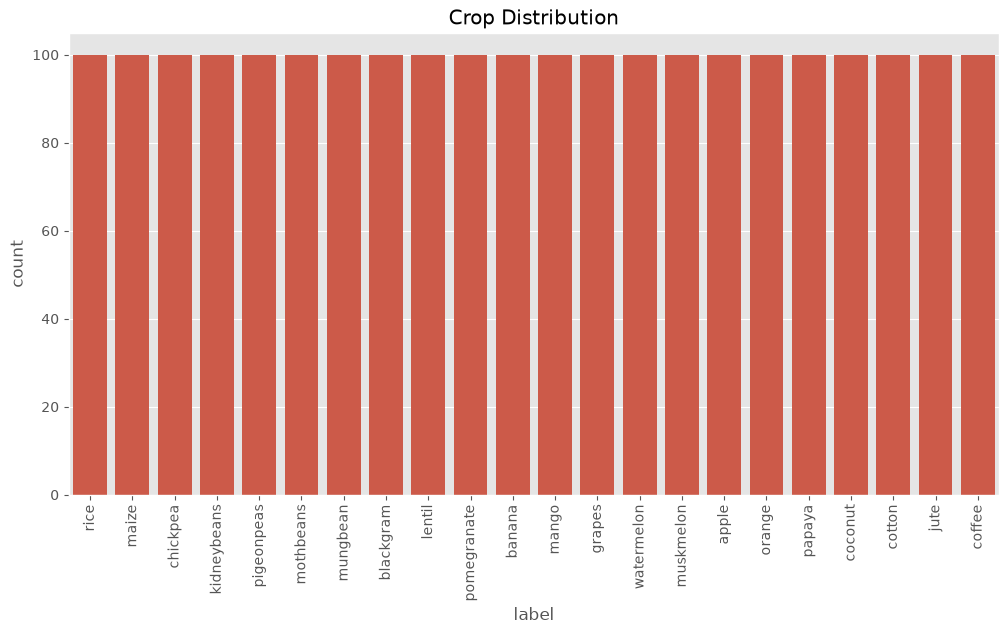

In [12]:
plt.figure(figsize=(12,6))

sns.countplot(data=df, x="label", order=df["label"].value_counts().index)

plt.title("Crop Distribution")
plt.xticks(rotation=90)

plt.show()

## Distribution of Numerical Features

Plot histograms to understand the distribution of each numerical feature.

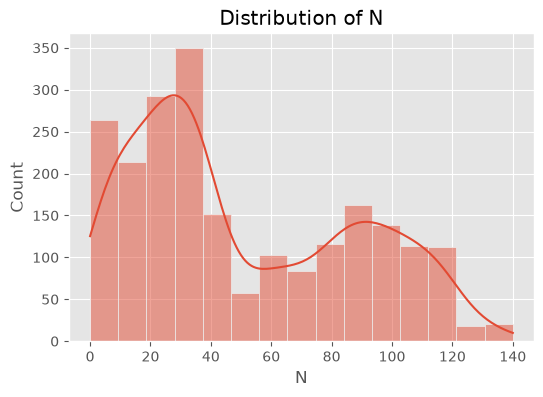

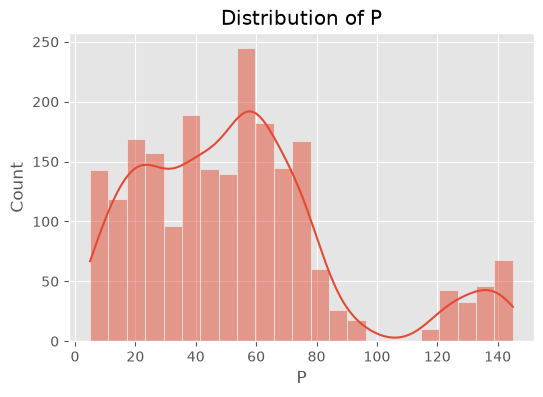

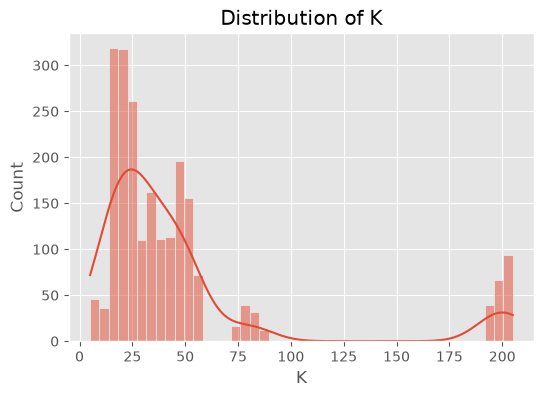

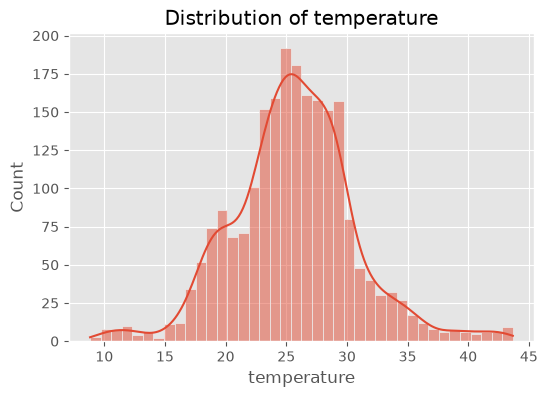

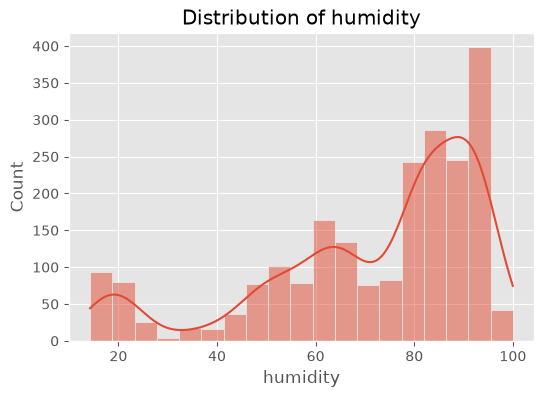

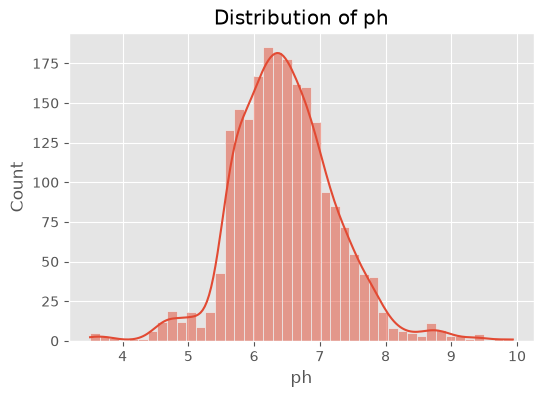

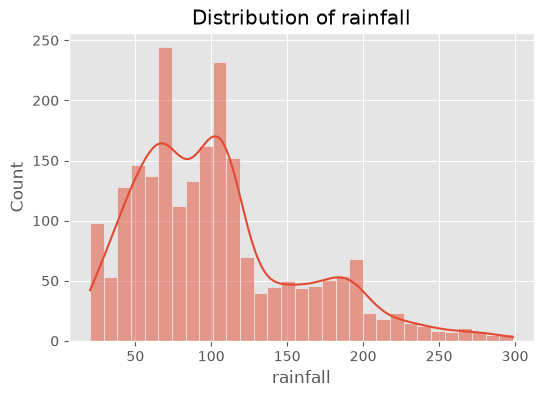

In [13]:
numerical_features = [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
]

for feature in numerical_features:
    plt.figure(figsize=(6,4))

    sns.histplot(df[feature], kde=True)

    plt.title(f"Distribution of {feature}")

    plt.show()

## Boxplots

Use boxplots to identify outliers and visualize the spread of each numerical feature.

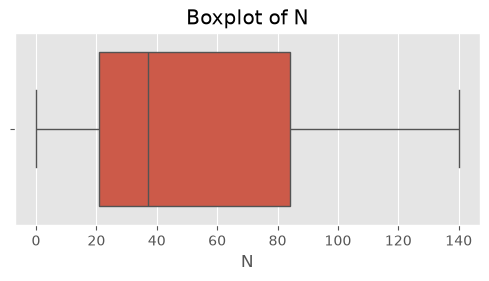

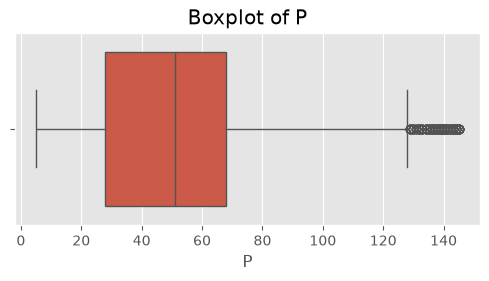

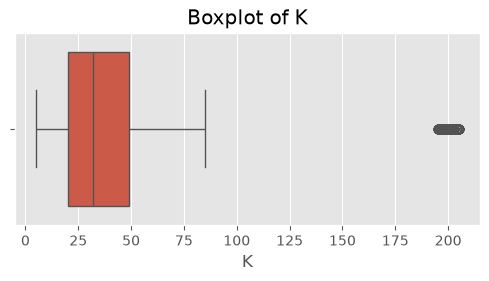

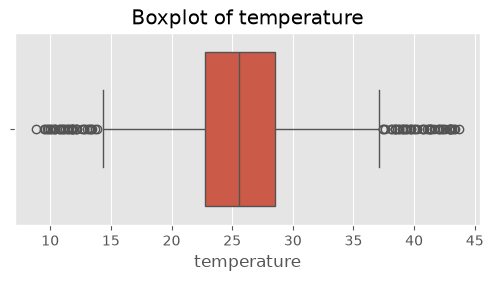

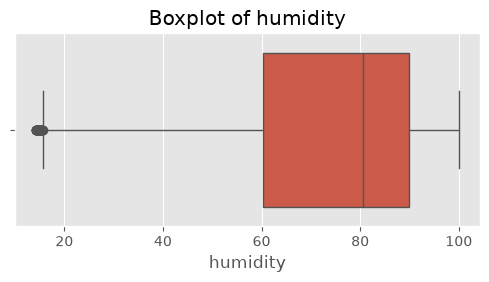

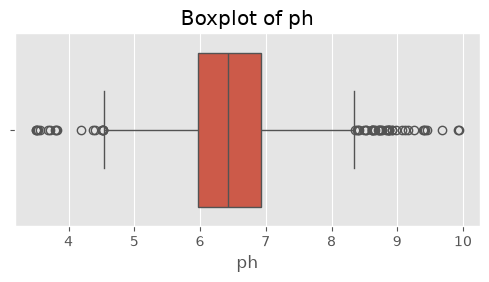

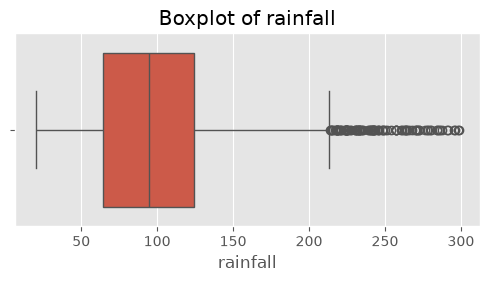

In [14]:
for feature in numerical_features:

    plt.figure(figsize=(6,2.5))

    sns.boxplot(x=df[feature])

    plt.title(f"Boxplot of {feature}")

    plt.show()

## Correlation Heatmap

Display the correlation between numerical features.

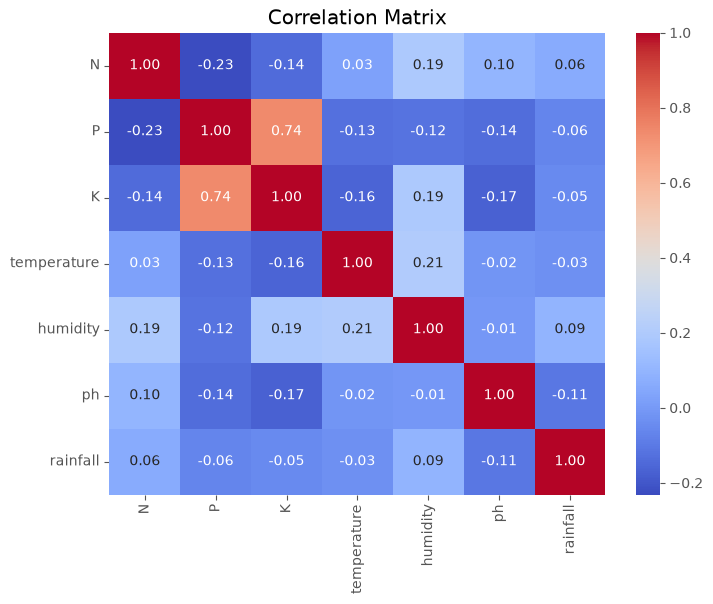

In [15]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## Pairplot

Visualize relationships among numerical features using a sample of the dataset.`

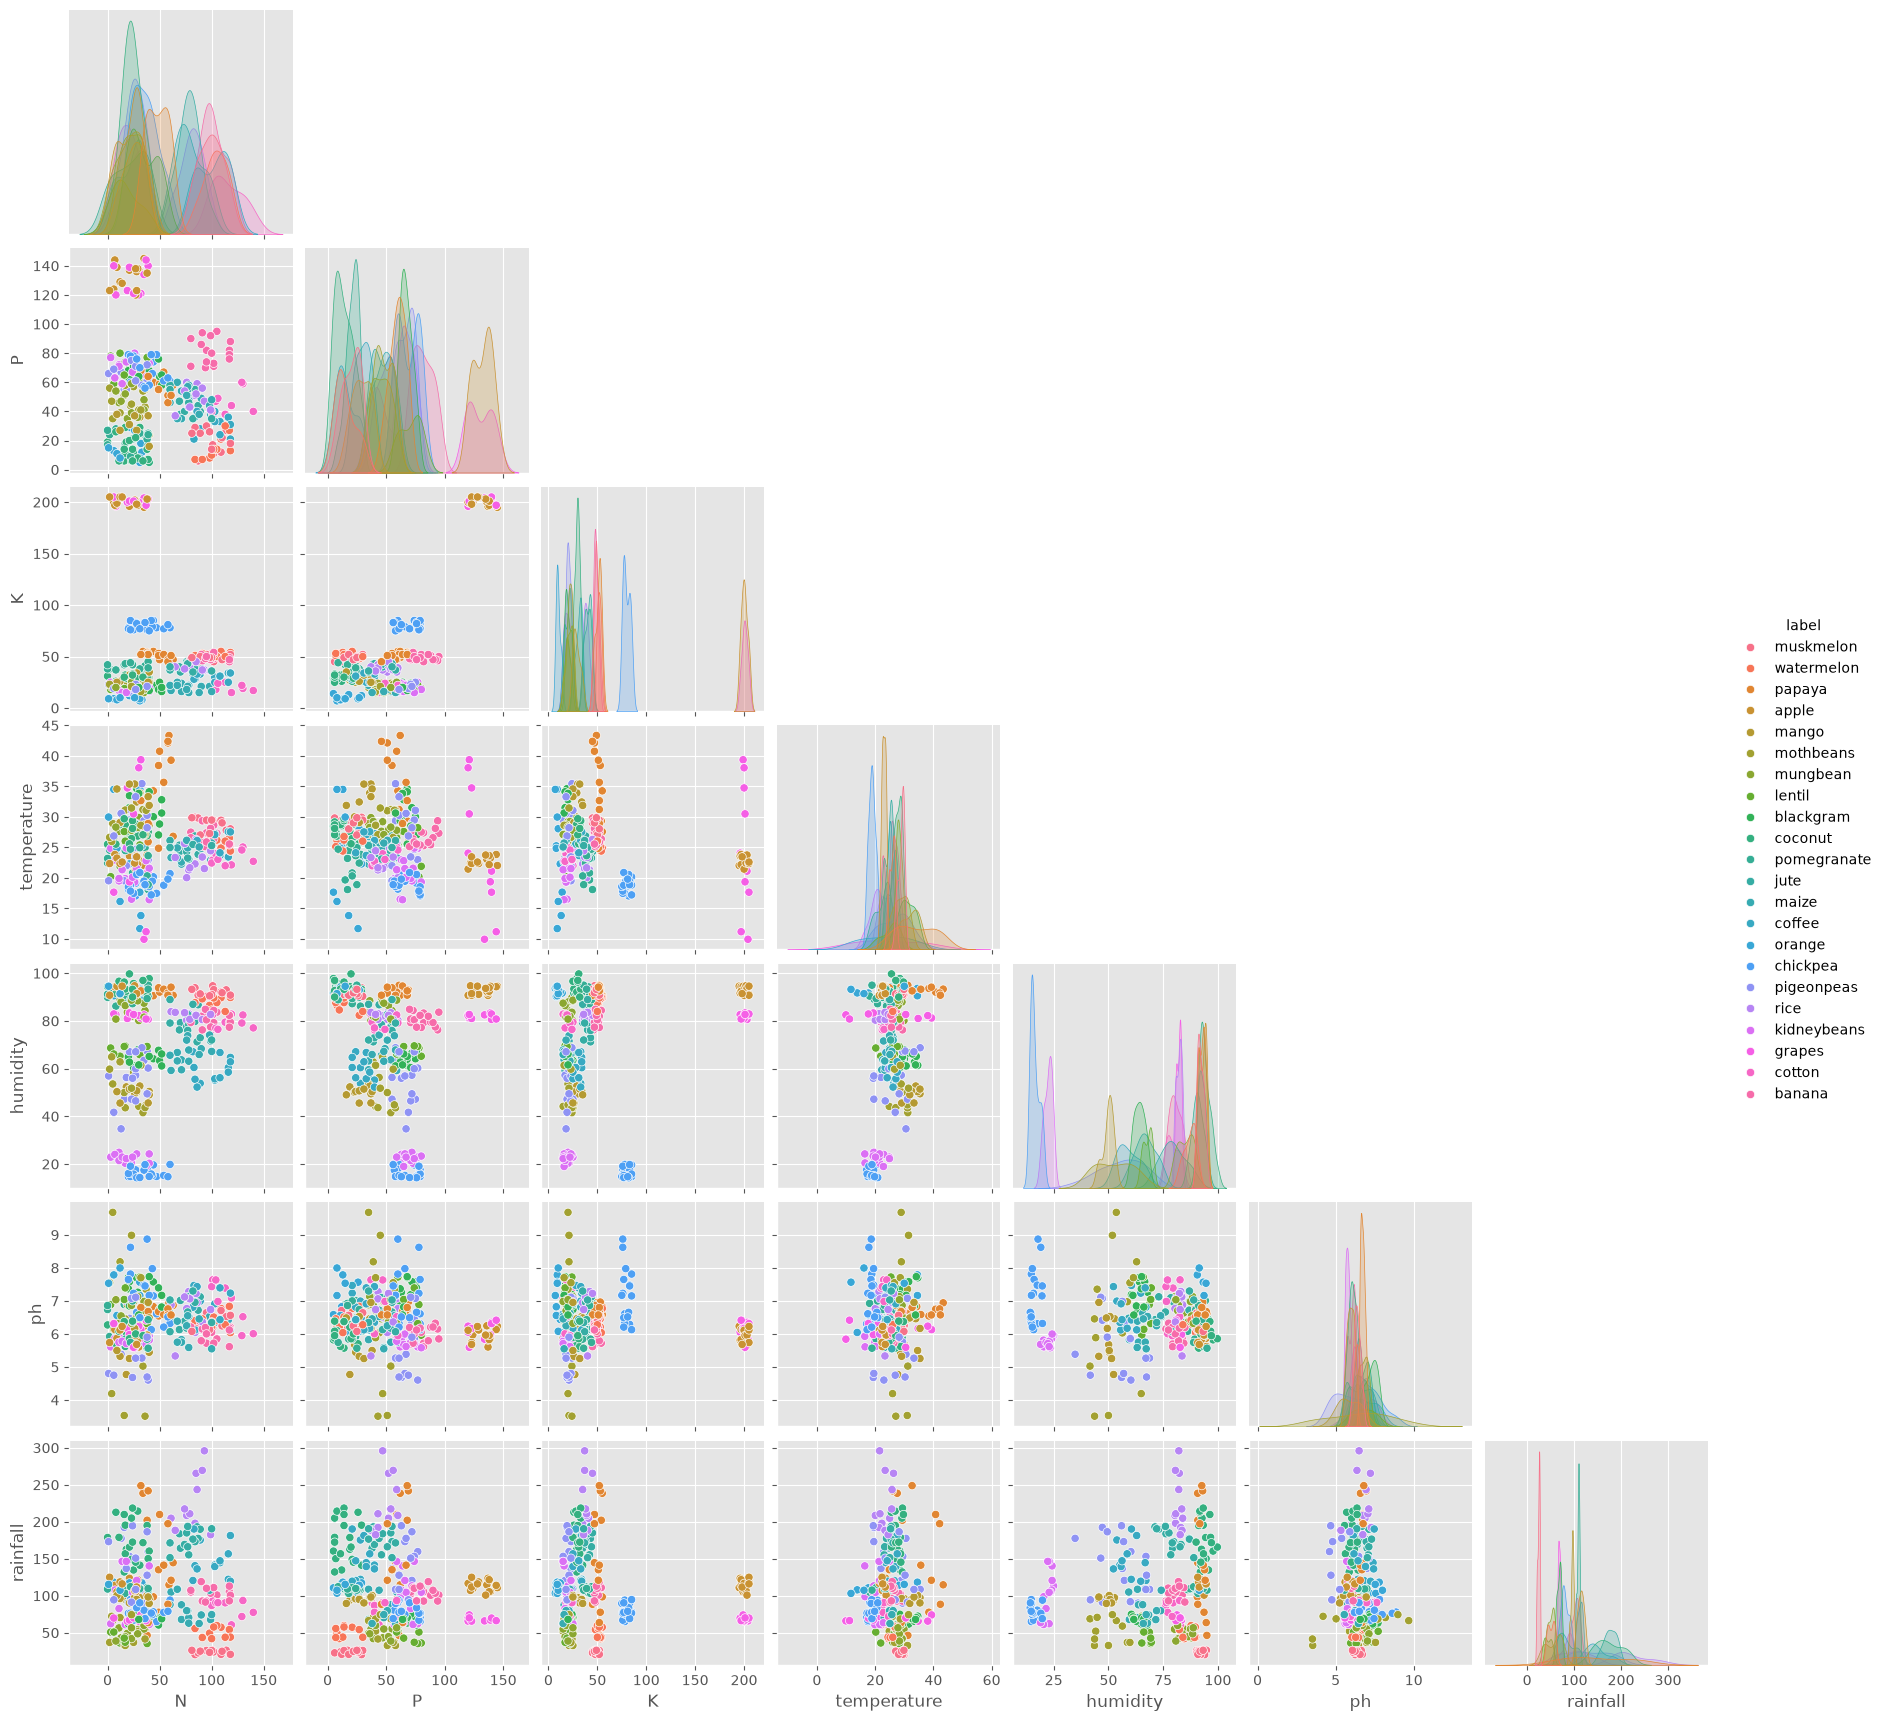

In [16]:
sns.pairplot(
    df.sample(300, random_state=42),
    hue="label",
    corner=True
)

plt.show()

## Average Feature Values by Crop

Calculate the average value of each numerical feature for every crop.

In [18]:
crop_mean = df.groupby("label").mean(numeric_only=True)

crop_mean.head()

,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
apple,20.80,134.22,199.89,22.630942,92.333383,5.929663,112.654779
banana,100.23,82.01,50.05,27.376798,80.358123,5.983893,104.626980
blackgram,40.02,67.47,19.24,29.973340,65.118426,7.133952,67.884151
chickpea,40.09,67.79,79.92,18.872847,16.860439,7.336957,80.058977
coconut,21.98,16.93,30.59,27.409892,94.844272,5.976562,175.686646


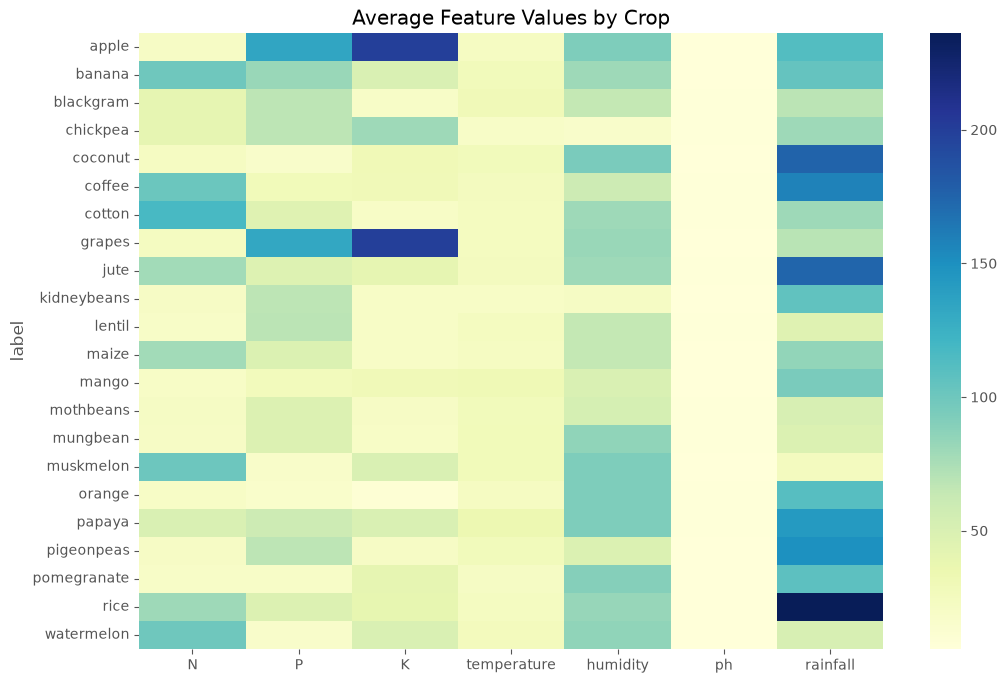

In [19]:
plt.figure(figsize=(12,8))

sns.heatmap(
    crop_mean,
    cmap="YlGnBu"
)

plt.title("Average Feature Values by Crop")

plt.show()

## Missing Value Verification

Verify that no missing values remain after preprocessing.

In [21]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

## Duplicate Verification

Verify that duplicate records have been removed.

In [22]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## Save Important Figures

Save the correlation heatmap for use in the project report.

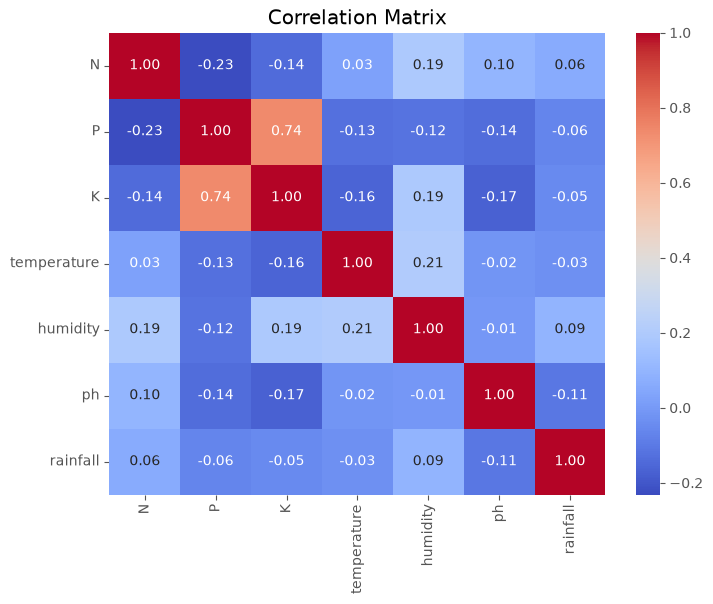

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.savefig("../outputs/correlation_heatmap.png", dpi=300)

plt.show()

# Conclusion

The exploratory data analysis provides an overview of the cleaned dataset. The visualizations help understand feature distributions, identify outliers, observe relationships among variables, and verify that the dataset is ready for machine learning model development.m